In [1]:
!git clone https://github.com/Team-TUD/CTAB-GAN-Plus
import sys
sys.path.append('./CTAB-GAN-Plus')
from model.ctabgan import CTABGAN

fatal: destination path 'CTAB-GAN-Plus' already exists and is not an empty directory.


In [22]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality

# ----------------------------------------------------
# Load Dataset
# ----------------------------------------------------
metro_interstate_traffic_volume = fetch_ucirepo(id=492)

X = metro_interstate_traffic_volume.data.features.copy()
y = metro_interstate_traffic_volume.data.targets.copy()

# Drop date_time before any preprocessing or generator training.
X = X.drop(columns=['date_time'], errors='ignore')

print(metro_interstate_traffic_volume.metadata)
print(metro_interstate_traffic_volume.variables)

if isinstance(y, pd.DataFrame):
    if 'traffic_volume' in y.columns:
        target_col = 'traffic_volume'
    else:
        target_col = y.columns[0]
    y_series = y[target_col]
else:
    target_col = 'traffic_volume'
    y_series = pd.Series(y, name=target_col)

{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

In [23]:
# ----------------------------------------------------
# Preprocess features before synthetic data generation
# ----------------------------------------------------
# 1. Drop the date_time column from the dataset
# 2. Keep raw columns for CTABGAN
# 3. One-hot encode categoricals for WGAN / SDV / downstream ML
# ----------------------------------------------------

# Drop date_time (hour of data collected in local CST time).
X = X.drop(columns=['date_time'], errors='ignore')

# Raw tabular features for CTABGAN (expects categorical column names, not dummies).
X_ctab = X.copy()
for col in ['temp', 'rain_1h', 'snow_1h', 'clouds_all']:
    X_ctab[col] = pd.to_numeric(X_ctab[col], errors='coerce')
metro_data_ctab = pd.concat([X_ctab, y_series.reset_index(drop=True)], axis=1)
metro_data_ctab[target_col] = pd.to_numeric(metro_data_ctab[target_col], errors='coerce').fillna(0)
for col in ['holiday', 'weather_main', 'weather_description']:
    metro_data_ctab[col] = metro_data_ctab[col].fillna('None').astype(str)

# One-hot encode categorical columns for other generators.
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

metro_data = pd.concat([X, y_series.reset_index(drop=True)], axis=1)
metro_data = metro_data.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64)

print(f'Target variable: {target_col}')
print(f'date_time in features: {"date_time" in metro_data.columns}')
print(f'Encoded dataset shape: {metro_data.shape}')
print(f'CTABGAN raw dataset shape: {metro_data_ctab.shape}')

Target variable: traffic_volume
date_time in features: False
Encoded dataset shape: (48204, 62)
CTABGAN raw dataset shape: (48204, 8)


In [24]:
# ----------------------------------------------------
# Experiment Settings
# ----------------------------------------------------
N_SAMPLES = 1000          # random real samples drawn from full dataset
TEST_SIZE = 0.2           # 20% holdout for unseen TSTR evaluation
SEED = 42

# Speed controls (set FAST_MODE=False for full paper epochs)
FAST_MODE = True
DEV_MODE = False
RUN_QUALITY_EVAL = True

N_SYNTH_SAMPLES = 1000

_epoch_fast = 5 if FAST_MODE else None
CTABGAN_EPOCHS = _epoch_fast if FAST_MODE else 150
WGAN_EPOCHS = (10 if FAST_MODE else 100)  # WGAN needs more epochs on high-dim one-hot data
SDV_EPOCHS = _epoch_fast if FAST_MODE else 300

EVAL_SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

ALL_GENERATORS = [
    'CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula', 'WGAN_GP', 'CTABGAN'
]
GENERATORS_TO_EVAL = ALL_GENERATORS

# Randomly select 1000 samples from the full preprocessed dataset.
_sample_idx = metro_data.sample(n=N_SAMPLES, random_state=SEED).index
metro_data = metro_data.loc[_sample_idx].reset_index(drop=True)
metro_data_ctab = metro_data_ctab.loc[_sample_idx].reset_index(drop=True)

# 80% for generator training, 20% held out unseen for TSTR evaluation.
train_real, test_real = train_test_split(
    metro_data,
    test_size=TEST_SIZE,
    random_state=SEED,
)
train_real_ctab, test_real_ctab = train_test_split(
    metro_data_ctab,
    test_size=TEST_SIZE,
    random_state=SEED,
)
train_real = train_real.reset_index(drop=True)
test_real = test_real.reset_index(drop=True)
train_real_ctab = train_real_ctab.reset_index(drop=True)
test_real_ctab = test_real_ctab.reset_index(drop=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_real)
train_metadata = metadata

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

scores = {}
synthetic_datasets = {}
quality_results = []


def align_to_train_schema(df, reference_df, label_col):
    """Map raw or mixed-type rows to the one-hot numeric schema used by train_real."""
    df = df.copy()
    y = pd.to_numeric(df[label_col], errors='coerce').fillna(0)
    X = df.drop(columns=[label_col], errors='ignore')
    X_ref = reference_df.drop(columns=[label_col], errors='ignore')

    if X.select_dtypes(include=['object', 'string', 'category']).shape[1] > 0:
        X = pd.get_dummies(X, drop_first=True)

    X = X.reindex(columns=X_ref.columns, fill_value=0)
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64)

    out = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
    out.columns = reference_df.columns
    return out


print(f'Random subsample: {metro_data.shape}')
print(f'Generator training set (80%): {train_real.shape}')
print(f'Holdout test set (20%, unseen): {test_real.shape}')
print(f'DEV_MODE: {DEV_MODE} | FAST_MODE: {FAST_MODE} | quality eval: {RUN_QUALITY_EVAL}')
print(f'Generators enabled: {GENERATORS_TO_EVAL}')
print(f'Synthetic samples per generator: {N_SYNTH_SAMPLES}')

Random subsample: (1000, 62)
Generator training set (80%): (800, 62)
Holdout test set (20%, unseen): (200, 62)
DEV_MODE: False | FAST_MODE: True | quality eval: True
Generators enabled: ['CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula', 'WGAN_GP', 'CTABGAN']
Synthetic samples per generator: 1000


In [25]:
# ---------------------------------------------------
# SINGLE RUN — setup + CTABGAN
# ---------------------------------------------------
seed = SEED
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Train generators on 80% of the 1000-sample subset only.

# CTABGAN — train on raw categoricals (not one-hot encoded)
# Use holiday + weather_main only (weather_description is too high-cardinality
# for 800-row train split and triggers Cond/log errors in CTAB-GAN+).
CTABGAN_CATEGORICAL = ['holiday', 'weather_main']
CTABGAN_MIXED = {}
CTABGAN_GENERAL = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', target_col]
CTABGAN_INTEGER = ['clouds_all', target_col]
CTABGAN_NUMERIC = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']


def prepare_ctabgan_train_df(df, categorical_cols, numeric_cols, label_col):
    cols = categorical_cols + numeric_cols + [label_col]
    out = df[cols].copy()
    for col in categorical_cols:
        out[col] = out[col].fillna('None').astype(str)
    for col in numeric_cols + [label_col]:
        out[col] = pd.to_numeric(out[col], errors='coerce').fillna(0).astype(np.float64)
    return out


def encode_ctabgan_synthetic(synth_df, reference_df, label_col):
    """Map CTABGAN raw output to the one-hot layout used by other generators."""
    return align_to_train_schema(synth_df, reference_df, label_col)


if 'CTABGAN' in GENERATORS_TO_EVAL:
    import traceback
    try:
        data_path = 'metro_train.csv'
        ctab_train = prepare_ctabgan_train_df(
            train_real_ctab, CTABGAN_CATEGORICAL, CTABGAN_NUMERIC, target_col
        )
        ctab_train.to_csv(data_path, index=False)
        ctabgan = CTABGAN(
            raw_csv_path=data_path,
            test_ratio=0.01,
            categorical_columns=CTABGAN_CATEGORICAL,
            log_columns=[],
            mixed_columns=CTABGAN_MIXED,
            general_columns=CTABGAN_GENERAL,
            integer_columns=CTABGAN_INTEGER,
            problem_type={'Regression': target_col}
        )
        ctabgan.synthesizer.epochs = CTABGAN_EPOCHS
        ctabgan.fit()
        synthetic_ctabgan_raw = ctabgan.data_prep.inverse_prep(
            ctabgan.synthesizer.sample(N_SYNTH_SAMPLES)
        )
        synthetic_ctabgan = encode_ctabgan_synthetic(
            synthetic_ctabgan_raw, train_real, target_col
        )
        synthetic_datasets['CTABGAN'] = synthetic_ctabgan.copy()
        if RUN_QUALITY_EVAL:
            quality = evaluate_quality(
                real_data=train_real,
                synthetic_data=synthetic_ctabgan,
                metadata=train_metadata
            )
            scores['CTABGAN'] = quality.get_score()
            print('CTABGAN:', round(scores['CTABGAN'], 4))
        else:
            print('CTABGAN: trained (quality eval skipped)')
    except Exception as e:
        print('CTABGAN Failed:', e)
        traceback.print_exc()
else:
    print('CTABGAN: skipped (not in GENERATORS_TO_EVAL)')


100%|██████████| 5/5 [00:06<00:00,  1.21s/it]


Finished training in 6.074838638305664  seconds.
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1116.78it/s]|
Column Shapes Score: 91.55%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:06<00:00, 289.42it/s]|
Column Pair Trends Score: 84.89%

Overall Score (Average): 88.22%

CTABGAN: 0.8822


In [26]:
# ---------------------------------------------------
# WGAN-GP
# ---------------------------------------------------
if 'WGAN_GP' in GENERATORS_TO_EVAL:
    import traceback

    WGAN_CONTINUOUS = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', target_col]

    def postprocess_wgan_synthetic(synth_df, reference_df, continuous_cols):
        out = synth_df.reindex(columns=reference_df.columns).copy()
        dummy_cols = [c for c in reference_df.columns if c not in continuous_cols]
        for col in dummy_cols:
            out[col] = (out[col] >= 0.5).astype(np.float64)
        for col in continuous_cols:
            if col in out.columns:
                out[col] = out[col].clip(reference_df[col].min(), reference_df[col].max())
        return out.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float64)

    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        data_wgan = train_real.copy()
        data_wgan = data_wgan.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
        real_tensor = torch.tensor(data_wgan.to_numpy(), dtype=torch.float32)

        batch_size = min(32, len(train_real))
        latent_dim = 64
        data_dim = real_tensor.shape[1]
        loader = torch.utils.data.DataLoader(real_tensor, batch_size=batch_size, shuffle=True, drop_last=False)

        class Generator(nn.Module):
            def __init__(self):
                super().__init__()
                self.model = nn.Sequential(
                    nn.Linear(latent_dim, 128),
                    nn.LayerNorm(128),
                    nn.LeakyReLU(0.2),
                    nn.Linear(128, 256),
                    nn.LayerNorm(256),
                    nn.LeakyReLU(0.2),
                    nn.Linear(256, data_dim),
                )
            def forward(self, z):
                return self.model(z)

        class Critic(nn.Module):
            def __init__(self):
                super().__init__()
                self.model = nn.Sequential(
                    nn.Linear(data_dim, 256),
                    nn.LeakyReLU(0.2),
                    nn.Linear(256, 128),
                    nn.LeakyReLU(0.2),
                    nn.Linear(128, 1),
                )
            def forward(self, x):
                return self.model(x)

        generator = Generator().to(device)
        critic = Critic().to(device)
        optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.9))
        optimizer_C = optim.Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))

        def gradient_penalty(critic_model, real_samples, fake_samples):
            alpha = torch.rand(real_samples.size(0), 1, device=device).expand_as(real_samples)
            interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
            critic_interpolates = critic_model(interpolates)
            gradients = torch.autograd.grad(
                outputs=critic_interpolates,
                inputs=interpolates,
                grad_outputs=torch.ones_like(critic_interpolates),
                create_graph=True,
                retain_graph=True
            )[0]
            gradients = gradients.view(gradients.size(0), -1)
            return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

        for _ in range(WGAN_EPOCHS):
            for real_batch in loader:
                real_batch = real_batch.to(device)
                for _ in range(5):
                    z = torch.randn(real_batch.size(0), latent_dim, device=device)
                    fake_batch = generator(z).detach()
                    critic_real = critic(real_batch).mean()
                    critic_fake = critic(fake_batch).mean()
                    gp = gradient_penalty(critic, real_batch, fake_batch)
                    critic_loss = critic_fake - critic_real + 10 * gp
                    optimizer_C.zero_grad()
                    critic_loss.backward()
                    optimizer_C.step()
                z = torch.randn(real_batch.size(0), latent_dim, device=device)
                fake = generator(z)
                generator_loss = -critic(fake).mean()
                optimizer_G.zero_grad()
                generator_loss.backward()
                optimizer_G.step()

        generator.eval()
        synth_chunks = []
        sample_batch = 256
        with torch.no_grad():
            for start in range(0, N_SYNTH_SAMPLES, sample_batch):
                n = min(sample_batch, N_SYNTH_SAMPLES - start)
                z = torch.randn(n, latent_dim, device=device)
                synth_chunks.append(generator(z).cpu().numpy())
        synthetic_scaled = np.vstack(synth_chunks)
        synthetic_wgan = pd.DataFrame(synthetic_scaled, columns=data_wgan.columns)
        synthetic_wgan = postprocess_wgan_synthetic(synthetic_wgan, train_real, WGAN_CONTINUOUS)
        synthetic_wgan = align_to_train_schema(synthetic_wgan, train_real, target_col)
        synthetic_datasets['WGAN_GP'] = synthetic_wgan.copy()
        print('WGAN_GP: synthesis complete')

        del generator, critic, real_tensor
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print('WGAN_GP Failed (training/sampling):')
        traceback.print_exc()

    if 'WGAN_GP' in synthetic_datasets and RUN_QUALITY_EVAL:
        try:
            quality = evaluate_quality(
                real_data=train_real,
                synthetic_data=synthetic_datasets['WGAN_GP'],
                metadata=train_metadata
            )
            scores['WGAN_GP'] = quality.get_score()
            print('WGAN_GP:', round(scores['WGAN_GP'], 4))
        except Exception as e:
            print('WGAN_GP quality eval failed:', e)
            traceback.print_exc()
else:
    print('WGAN_GP: skipped (not in GENERATORS_TO_EVAL)')


WGAN_GP: synthesis complete
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 893.69it/s]|
Column Shapes Score: 85.47%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:05<00:00, 356.86it/s]|
Column Pair Trends Score: 76.18%

Overall Score (Average): 80.82%

WGAN_GP: 0.8082


In [27]:
# ---------------------------------------------------
# SDV Models (CTGAN, CopulaGAN, TVAE, GaussianCopula)
# ---------------------------------------------------
sdv_models = {
    'CTGAN': CTGANSynthesizer(metadata=train_metadata, epochs=SDV_EPOCHS),
    'CopulaGAN': CopulaGANSynthesizer(metadata=train_metadata, epochs=SDV_EPOCHS),
    'TVAE': TVAESynthesizer(metadata=train_metadata, epochs=SDV_EPOCHS),
    'GaussianCopula': GaussianCopulaSynthesizer(metadata=train_metadata),
}

for model_name, model in sdv_models.items():
    if model_name not in GENERATORS_TO_EVAL:
        print(f'{model_name}: skipped (not in GENERATORS_TO_EVAL)')
        continue
    try:
        model.fit(train_real)
        synthetic_data = model.sample(N_SYNTH_SAMPLES)
        synthetic_data = align_to_train_schema(synthetic_data, train_real, target_col)
        synthetic_datasets[model_name] = synthetic_data.copy()
        if RUN_QUALITY_EVAL:
            quality = evaluate_quality(
                real_data=train_real,
                synthetic_data=synthetic_data,
                metadata=train_metadata
            )
            scores[model_name] = quality.get_score()
            print(f'{model_name}: {round(scores[model_name], 4)}')
        else:
            print(f'{model_name}: trained (quality eval skipped)')
    except Exception as e:
        print(f'{model_name} Failed: {e}')


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1173.14it/s]|
Column Shapes Score: 77.12%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:04<00:00, 414.59it/s]|
Column Pair Trends Score: 59.04%

Overall Score (Average): 68.08%

CTGAN: 0.6808
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1869.76it/s]|
Column Shapes Score: 75.95%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:05<00:00, 349.93it/s]|
Column Pair Trends Score: 58.58%

Overall Score (Average): 67.26%

CopulaGAN: 0.6726
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1106.16it/s]|
Column Shapes Score: 94.73%

(2/2) Evaluating Column Pair Trends: |██████████| 1891/1891 [00:12<00:00, 152.03it/s]|
Column Pair Trends Score: 86.09%

Overall Score (Average): 90.41%

TVAE: 0.9041
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 62/62 [00:00<00:00, 1049.93it/s]

In [28]:
# Quality summary
quality_results = []
for gen_name in GENERATORS_TO_EVAL:
    quality_results.append({
        'Generator': gen_name,
        'Quality_Score': scores.get(gen_name, np.nan),
        'Status': 'Success' if gen_name in synthetic_datasets else 'Failed'
    })

quality_df = pd.DataFrame(quality_results).sort_values('Quality_Score', ascending=False)
display(quality_df)

,Generator,Quality_Score,Status
3,GaussianCopula,0.953769,Success
2,TVAE,0.904123,Success
5,CTABGAN,0.882190,Success
4,WGAN_GP,0.808212,Success
0,CTGAN,0.680841,Success
1,CopulaGAN,0.672640,Success


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 61/61 [00:00<00:00, 1262.98it/s]|
Column Shapes Score: 92.27%



(2/2) Evaluating Column Pair Trends: |██████████| 1830/1830 [00:06<00:00, 272.19it/s]|
Column Pair Trends Score: 85.54%

Overall Score (Average): 88.91%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 61/61 [00:00<00:00, 1211.23it/s]|
Column Shapes Score: 86.89%

(2/2) Evaluating Column Pair Trends: |██████████| 1830/1830 [00:06<00:00, 288.55it/s]|
Column Pair Trends Score: 76.68%

Overall Score (Average): 81.78%



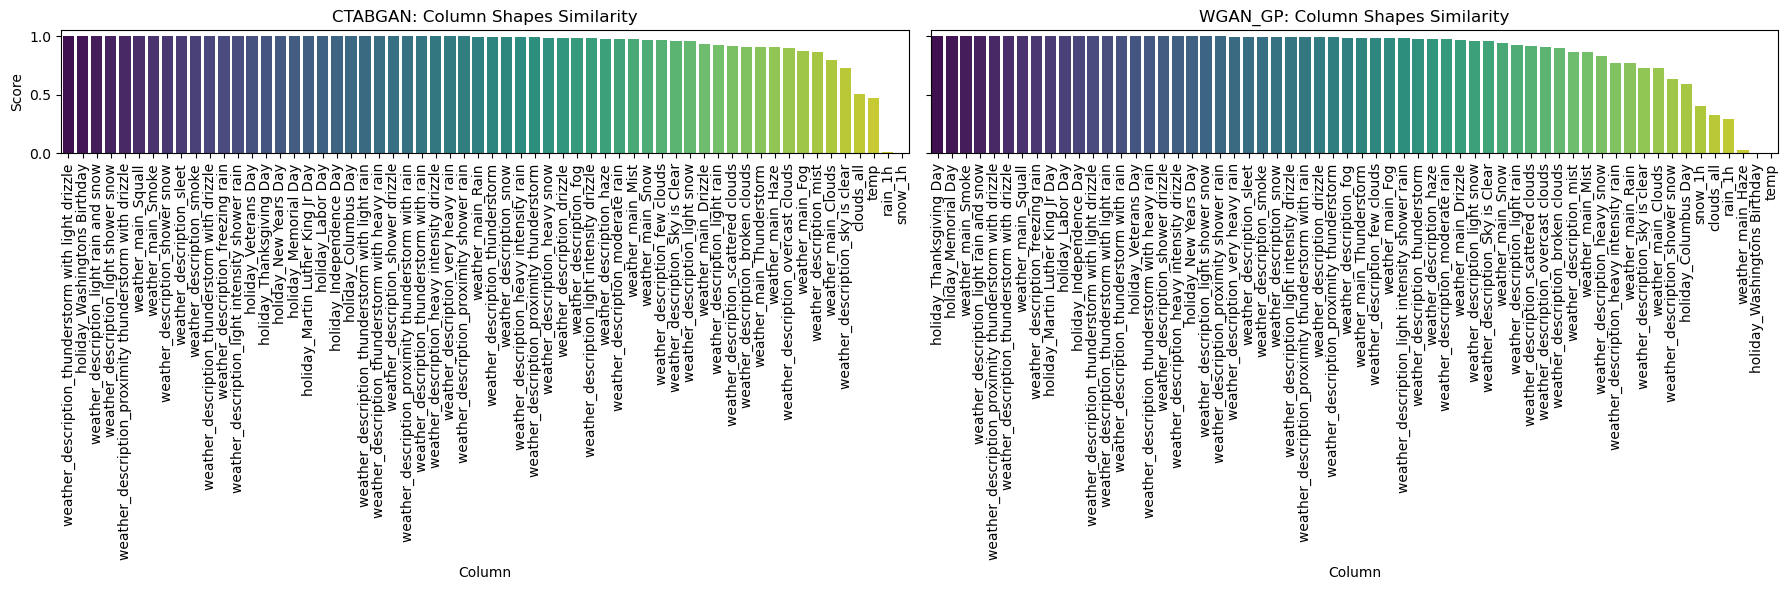

,Column,Metric,Score,Model
0,weather_description_thunderstorm with light dr...,TVComplement,1.0,CTABGAN
1,holiday_Washingtons Birthday,TVComplement,1.0,CTABGAN
2,weather_description_light rain and snow,TVComplement,1.0,CTABGAN
3,weather_description_light shower snow,TVComplement,1.0,CTABGAN
4,weather_description_proximity thunderstorm wit...,TVComplement,1.0,CTABGAN
5,weather_main_Squall,TVComplement,1.0,CTABGAN
6,weather_main_Smoke,TVComplement,1.0,CTABGAN
7,weather_description_shower snow,TVComplement,1.0,CTABGAN
8,weather_description_sleet,TVComplement,1.0,CTABGAN
9,weather_description_smoke,TVComplement,1.0,CTABGAN


In [29]:
# ---------------------------------------------------
# Column Shapes Quality Report (per generator)
# ---------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns

# Generators to compare (only those with synthetic output available).
model_order = [m for m in ['CTABGAN', 'WGAN_GP'] if m in synthetic_datasets]

if not model_order:
    print('No synthetic datasets available for column-shape comparison.')
else:
    real_eval = train_real.drop(columns=[target_col], errors='ignore').copy()

    metadata_eval = SingleTableMetadata()
    metadata_eval.detect_from_dataframe(real_eval)

    column_shape_details = {}

    for model_name in model_order:
        synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors='ignore').copy()
        synth_eval = synth_eval[real_eval.columns]

        qr = QualityReport()
        qr.generate(
            real_data=real_eval,
            synthetic_data=synth_eval,
            metadata=metadata_eval.to_dict()
        )

        details = qr.get_details('Column Shapes').sort_values('Score', ascending=False)
        column_shape_details[model_name] = details

    fig, axes = plt.subplots(1, len(model_order), figsize=(9 * len(model_order), 6), sharey=True)
    if len(model_order) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, model_order):
        details = column_shape_details[model_name]

        sns.barplot(
            x='Column',
            y='Score',
            data=details,
            palette='viridis',
            ax=ax
        )

        ax.set_title(f'{model_name}: Column Shapes Similarity')
        ax.tick_params(axis='x', rotation=90)
        ax.set_xlabel('Column')
        ax.set_ylabel('Score')

    plt.tight_layout()
    plt.show()

    combined_details = pd.concat(
        [df.assign(Model=name) for name, df in column_shape_details.items()],
        ignore_index=True
    )

    display(combined_details.head(20))

In [30]:
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

regressors = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    'SVR_RBF': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
}

print(f'Regression evaluation: {len(regressors)} models, {len(EVAL_SEEDS)} seeds, {len(GENERATORS_TO_EVAL)} generators')


Regression evaluation: 10 models, 10 seeds, 6 generators


In [31]:
def evaluate_regression_models(train_df, test_df, label_col, models, test_size=0.2, seeds=None, use_holdout=False, schema_df=None):
    if seeds is None:
        seeds = EVAL_SEEDS
    if schema_df is None:
        schema_df = test_df if use_holdout else train_df

    train_df = align_to_train_schema(train_df, schema_df, label_col)
    test_df = align_to_train_schema(test_df, schema_df, label_col)
    results = []

    for name, model in models.items():
        r2_scores = []
        mse_scores = []
        rmse_scores = []
        mae_scores = []

        for seed in seeds:
            X_train = train_df.drop(columns=[label_col])
            y_train = train_df[label_col]

            X_test = test_df.drop(columns=[label_col])
            y_test = test_df[label_col]

            if not use_holdout:
                X_train, _, y_train, _ = train_test_split(
                    X_train, y_train, test_size=test_size, random_state=seed
                )
                _, X_test, _, y_test = train_test_split(
                    X_test, y_test, test_size=test_size, random_state=seed
                )

            reg = clone(model)
            if 'random_state' in reg.get_params():
                reg.set_params(random_state=seed)

            reg.fit(X_train, y_train)
            y_pred = reg.predict(X_test)

            mse = mean_squared_error(y_test, y_pred)
            r2_scores.append(r2_score(y_test, y_pred))
            mse_scores.append(mse)
            rmse_scores.append(np.sqrt(mse))
            mae_scores.append(mean_absolute_error(y_test, y_pred))

        results.append({
            'Model': name,
            'R2 Mean': np.mean(r2_scores),
            'R2 Std': np.std(r2_scores),
            'MSE Mean': np.mean(mse_scores),
            'MSE Std': np.std(mse_scores),
            'RMSE Mean': np.mean(rmse_scores),
            'RMSE Std': np.std(rmse_scores),
            'MAE Mean': np.mean(mae_scores),
            'MAE Std': np.std(mae_scores),
            'R2 (Mean±Std)': f"{np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}",
            'MSE (Mean±Std)': f"{np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}",
            'RMSE (Mean±Std)': f"{np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}",
            'MAE (Mean±Std)': f"{np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}",
        })

    return pd.DataFrame(results).sort_values(by='R2 Mean', ascending=False)


In [32]:
print('TRTR (Train Real, Test Real) — 80% train / 20% holdout')
trtr_results = evaluate_regression_models(
    train_df=train_real,
    test_df=test_real,
    label_col=target_col,
    models=regressors,
    seeds=EVAL_SEEDS,
    use_holdout=True,
    schema_df=train_real,
)
display(trtr_results[['Model', 'R2 (Mean±Std)', 'MSE (Mean±Std)', 'RMSE (Mean±Std)', 'MAE (Mean±Std)']])

all_comparisons = []
for synth_name in GENERATORS_TO_EVAL:
    if synth_name not in synthetic_datasets:
        print(f'Skipping {synth_name} - no synthetic dataset')
        continue

    print(f'{synth_name} - TSTR (train on synthetic, test on 20% holdout)')
    tstr_results = evaluate_regression_models(
        train_df=synthetic_datasets[synth_name],
        test_df=test_real,
        label_col=target_col,
        models=regressors,
        seeds=EVAL_SEEDS,
        use_holdout=True,
        schema_df=train_real,
    )
    display(tstr_results[['Model', 'R2 (Mean±Std)', 'MSE (Mean±Std)', 'RMSE (Mean±Std)', 'MAE (Mean±Std)']])

    comparison = trtr_results.merge(tstr_results, on='Model', suffixes=('_TRTR', '_TSTR'))
    comparison['R2_Drop'] = comparison['R2 Mean_TRTR'] - comparison['R2 Mean_TSTR']
    comparison['MSE_Increase'] = comparison['MSE Mean_TSTR'] - comparison['MSE Mean_TRTR']
    comparison['RMSE_Increase'] = comparison['RMSE Mean_TSTR'] - comparison['RMSE Mean_TRTR']
    comparison['MAE_Increase'] = comparison['MAE Mean_TSTR'] - comparison['MAE Mean_TRTR']
    comparison['Synthetic_Model'] = synth_name
    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)
summary = (
    combined_comparison
    .groupby('Synthetic_Model', as_index=False)[['R2_Drop', 'MSE_Increase', 'RMSE_Increase', 'MAE_Increase']]
    .mean()
    .sort_values('R2_Drop')
)

display(summary)


TRTR (Train Real, Test Real) — 80% train / 20% holdout


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
3,ElasticNet,0.0476 ± 0.0000,3965376.0377 ± 0.0000,1991.3252 ± 0.0000,1758.3707 ± 0.0000
1,Ridge,0.0455 ± 0.0000,3974046.1682 ± 0.0000,1993.5010 ± 0.0000,1766.2170 ± 0.0000
9,GradientBoost,0.0266 ± 0.0010,4053008.8613 ± 4338.1755,2013.2083 ± 1.0772,1763.4375 ± 0.6370
2,Lasso,0.0221 ± 0.0000,4071408.9823 ± 0.0000,2017.7733 ± 0.0000,1768.2359 ± 0.0000
0,LinearRegression,0.0218 ± 0.0000,4072730.5922 ± 0.0000,2018.1007 ± 0.0000,1768.2003 ± 0.0000
4,SVR_RBF,-0.0439 ± 0.0000,4346479.0431 ± 0.0000,2084.8211 ± 0.0000,1880.7804 ± 0.0000
5,KNN,-0.1754 ± 0.0000,4893854.9594 ± 0.0000,2212.2059 ± 0.0000,1939.9790 ± 0.0000
7,RandomForest,-0.2344 ± 0.0126,5139450.1795 ± 52391.9622,2267.0062 ± 11.5301,1930.9999 ± 13.2027
8,ExtraTrees,-0.5412 ± 0.0073,6416983.2359 ± 30384.2417,2533.1694 ± 6.0001,2061.4442 ± 5.5767
6,DecisionTree,-0.9714 ± 0.0144,8208006.9225 ± 59934.2179,2864.9428 ± 10.4755,2310.0295 ± 15.7290


CTGAN - TSTR (train on synthetic, test on 20% holdout)


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
0,LinearRegression,-0.0458 ± 0.0000,4354343.0774 ± 0.0000,2086.7063 ± 0.0000,1888.4613 ± 0.0000
2,Lasso,-0.0458 ± 0.0000,4354345.4629 ± 0.0000,2086.7068 ± 0.0000,1888.4613 ± 0.0000
3,ElasticNet,-0.0459 ± 0.0000,4354537.0781 ± 0.0000,2086.7528 ± 0.0000,1888.4744 ± 0.0000
1,Ridge,-0.0459 ± 0.0000,4354728.1488 ± 0.0000,2086.7985 ± 0.0000,1888.4873 ± 0.0000
4,SVR_RBF,-0.0846 ± 0.0000,4515642.1149 ± 0.0000,2125.0040 ± 0.0000,1898.1128 ± 0.0000
7,RandomForest,-0.1098 ± 0.0275,4620776.8203 ± 114323.5675,2149.4329 ± 26.7423,1920.1650 ± 16.8387
9,GradientBoost,-0.1107 ± 0.0001,4624595.9823 ± 374.2213,2150.4874 ± 0.0870,1896.1298 ± 0.1463
8,ExtraTrees,-0.2066 ± 0.0440,5023708.5178 ± 183260.4019,2240.9949 ± 40.6271,1971.5075 ± 20.0044
5,KNN,-0.3002 ± 0.0000,5413713.5140 ± 0.0000,2326.7388 ± 0.0000,1977.2340 ± 0.0000
6,DecisionTree,-1.3509 ± 0.0838,9788405.1055 ± 348807.0008,3128.1492 ± 55.5691,2521.6655 ± 66.2824


CopulaGAN - TSTR (train on synthetic, test on 20% holdout)


...

WGAN_GP - TSTR (train on synthetic, test on 20% holdout)


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
0,LinearRegression,-2.0148 ± 0.0000,12552398.3378 ± 0.0000,3542.9364 ± 0.0000,2896.2256 ± 0.0000
1,Ridge,-2.0151 ± 0.0000,12553628.2442 ± 0.0000,3543.1100 ± 0.0000,2896.4466 ± 0.0000
3,ElasticNet,-2.0166 ± 0.0000,12559743.5360 ± 0.0000,3543.9728 ± 0.0000,2897.5426 ± 0.0000
2,Lasso,-2.0181 ± 0.0000,12566083.5980 ± 0.0000,3544.8672 ± 0.0000,2898.6749 ± 0.0000
4,SVR_RBF,-2.0191 ± 0.0000,12570482.7226 ± 0.0000,3545.4877 ± 0.0000,2899.4608 ± 0.0000
6,DecisionTree,-2.0191 ± 0.0000,12570551.6792 ± 29.1792,3545.4974 ± 0.0041,2899.4732 ± 0.0048
8,ExtraTrees,-2.0192 ± 0.0000,12570713.8625 ± 31.7020,3545.5203 ± 0.0045,2899.5049 ± 0.0051
7,RandomForest,-2.0192 ± 0.0000,12570895.0745 ± 42.6068,3545.5458 ± 0.0060,2899.5323 ± 0.0073
5,KNN,-2.0193 ± 0.0000,12570989.3740 ± 0.0000,3545.5591 ± 0.0000,2899.5484 ± 0.0000
9,GradientBoost,-2.0193 ± 0.0000,12571225.8390 ± 23.3798,3545.5925 ± 0.0033,2899.5911 ± 0.0044


CTABGAN - TSTR (train on synthetic, test on 20% holdout)


,Model,R2 (Mean±Std),MSE (Mean±Std),RMSE (Mean±Std),MAE (Mean±Std)
4,SVR_RBF,-0.0459 ± 0.0000,4354570.2437 ± 0.0000,2086.7607 ± 0.0000,1882.1811 ± 0.0000
9,GradientBoost,-0.0602 ± 0.0019,4414112.0791 ± 8065.7464,2100.9780 ± 1.9197,1876.8192 ± 1.4757
7,RandomForest,-0.0892 ± 0.0042,4535135.4821 ± 17310.9819,2129.5819 ± 4.0643,1912.7284 ± 2.3512
5,KNN,-0.1016 ± 0.0000,4586737.6492 ± 0.0000,2141.6670 ± 0.0000,1929.6400 ± 0.0000
3,ElasticNet,-0.1046 ± 0.0000,4598925.3931 ± 0.0000,2144.5105 ± 0.0000,1940.1223 ± 0.0000
2,Lasso,-0.1058 ± 0.0000,4604318.1914 ± 0.0000,2145.7675 ± 0.0000,1933.0571 ± 0.0000
0,LinearRegression,-0.1059 ± 0.0000,4604524.8566 ± 0.0000,2145.8157 ± 0.0000,1933.0587 ± 0.0000
1,Ridge,-0.1065 ± 0.0000,4607046.8599 ± 0.0000,2146.4032 ± 0.0000,1941.1037 ± 0.0000
8,ExtraTrees,-0.1071 ± 0.0051,4609481.5458 ± 21301.4448,2146.9646 ± 4.9614,1925.5460 ± 3.3883
6,DecisionTree,-0.1889 ± 0.0105,4950307.8040 ± 43549.7525,2224.9072 ± 9.7792,1953.8990 ± 11.0562


,Synthetic_Model,R2_Drop,MSE_Increase,RMSE_Increase,MAE_Increase
0,CTABGAN,-0.078686,-3.276185e+05,-58.269762,28.046103
2,CopulaGAN,0.016041,6.678871e+04,11.040420,57.651259
1,CTGAN,0.054363,2.263451e+05,47.171760,79.100474
3,GaussianCopula,0.135213,5.629732e+05,114.931281,98.688100
4,TVAE,0.492376,2.050062e+06,425.014597,213.849930
5,WGAN_GP,1.837718,7.651537e+06,1345.203516,1003.830612


In [33]:
output_file = 'TRTR_TSTR_results_regression.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    quality_df.to_excel(writer, sheet_name='Quality_Metrics', index=False)
    trtr_results.to_excel(writer, sheet_name='TRTR_Results', index=False)
    combined_comparison.to_excel(writer, sheet_name='All_Comparisons', index=False)
    summary.to_excel(writer, sheet_name='Summary', index=False)
    for synth_name in GENERATORS_TO_EVAL:
        if synth_name in combined_comparison['Synthetic_Model'].values:
            synth_results = combined_comparison[combined_comparison['Synthetic_Model'] == synth_name]
            synth_results.to_excel(writer, sheet_name=synth_name[:31], index=False)

print(f'Results saved to: {output_file}')


Results saved to: TRTR_TSTR_results_regression.xlsx
